In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Optional
from scipy import stats
from datasets import (
    Dataset
)


In [89]:
df = pd.read_parquet("../reports/metrics/fleurs-summary.parquet")
df2 = pd.read_parquet("../reports/metrics/coral-v2-summary.parquet")

data = pd.concat([df, df2], ignore_index=True)

data.columns

Index(['id_recording', 'voiced_ratio', 'mean_pitch_hz', 'median_pitch_hz',
       'id', 'num_samples', 'path', 'transcription', 'raw_transcription',
       'gender', 'lang_id', 'language', 'lang_group_id', 'clip_length',
       'dataset_name', 'id_sentence', 'id_speaker', 'text', 'location',
       'location_roomdim', 'noise_level', 'noise_type', 'source_url', 'age',
       'dialect', 'country_birth', 'validated', 'asr_prediction',
       'asr_validation_model', 'asr_cer', 'asr_wer'],
      dtype='object')

In [104]:
def load_from_parquet(parquet_path: Path) -> pd.DataFrame:
    """Load a DataFrame from a Parquet file.

    Args:
        csv_path:
            Path to the CSV file.

    Returns:
        Loaded DataFrame.
    """
    return pd.read_parquet(parquet_path)


df = load_from_parquet(Path("../reports/metrics/combined_detailed_results_with_embeddings.parquet"))

# filter to only include fleurs
df = df[df["dataset_name"] == "coral-v2"]

df.head()

,id,prediction,label,clip_length,CER,WER,model,dataset_name,dataset_subset,dataset_split,...,dialect,country_birth,validated,asr_prediction,asr_validation_model,asr_cer,asr_wer,prediction_embedding,label_embedding,semantic_distance
0,rec_90dda503d68dc197f80219a7d3b129a9,derimod udøves retsplanen i det hele i det tid...,derimod udøvedes retsplejen i det hele i det t...,10.26,0.104167,0.266667,whisper-large-v3,coral-v2,read_aloud,test,...,vestjysk,DK,maybe,derimod udøves rets plan i det hele i det tidl...,alexandrainst/coral-asr-bootstrap,0.125000,0.400000,"[-0.014361421, 0.05218921, -0.018706942, -0.09...","[-0.03685369, 0.03144104, -0.037021983, -0.117...",0.166795
1,rec_becc6eb53b441b31116584cd5c4e1c51,bauer klønge støtter kløngeorganisationer til ...,begge klynger støttes af klyngeorganisationer ...,7.32,0.234568,0.727273,whisper-large-v3,coral-v2,read_aloud,test,...,vestjysk,DK,approved,bare klynger støttede sig af klyngeorganisatio...,alexandrainst/coral-asr-bootstrap,0.160494,0.454545,"[-0.07104228, -0.12548853, -0.06338177, -0.015...","[-0.0125311585, -0.060128797, -0.007917432, -0...",0.517030
2,rec_e59f62c2675fea5f9e7e726b51283250,i mildere tilfælde kan asmalt klare sig med pa...,i mildere tilfælde kan smerterne klares med pa...,8.10,0.147059,0.300000,whisper-large-v3,coral-v2,read_aloud,test,...,vestjysk,DK,approved,i mildere tilfælde kan smerterne klares med pa...,alexandrainst/coral-asr-bootstrap,0.000000,0.200000,"[0.019092456, -0.023992827, -0.031023178, 0.02...","[0.03683996, -0.028660791, 0.04380101, 0.11237...",0.347441
3,rec_a47501841f128c1e6eb7fdd21647aa14,grønt er et ørelov liges her gennem og umanget...,grant at ødelægge lees hær gennem udmattelse v...,9.96,0.376344,0.857143,whisper-large-v3,coral-v2,read_aloud,test,...,vestjysk,DK,approved,grænsen er ødelagt lees hær gennem udmattelse ...,alexandrainst/coral-asr-bootstrap,0.215054,0.500000,"[0.028158227, -0.008324441, 0.06434102, -0.056...","[-0.04051919, 0.16661945, 0.01602321, -0.03350...",0.748699
4,rec_9a4da4e1a39901165014ad7354ac8e4f,der er lavet scenarier der forsøger at vise hv...,der er lavet scenarier der søger at vise hvord...,5.82,0.038462,0.071429,whisper-large-v3,coral-v2,read_aloud,test,...,vestjysk,DK,maybe,der er lavet senarier der forsøger at vise hvo...,alexandrainst/coral-asr-bootstrap,0.051282,0.214286,"[-0.12290491, -0.02050186, 0.007368673, -0.010...","[-0.11009042, -0.02908404, 0.0042077433, -0.00...",0.019895


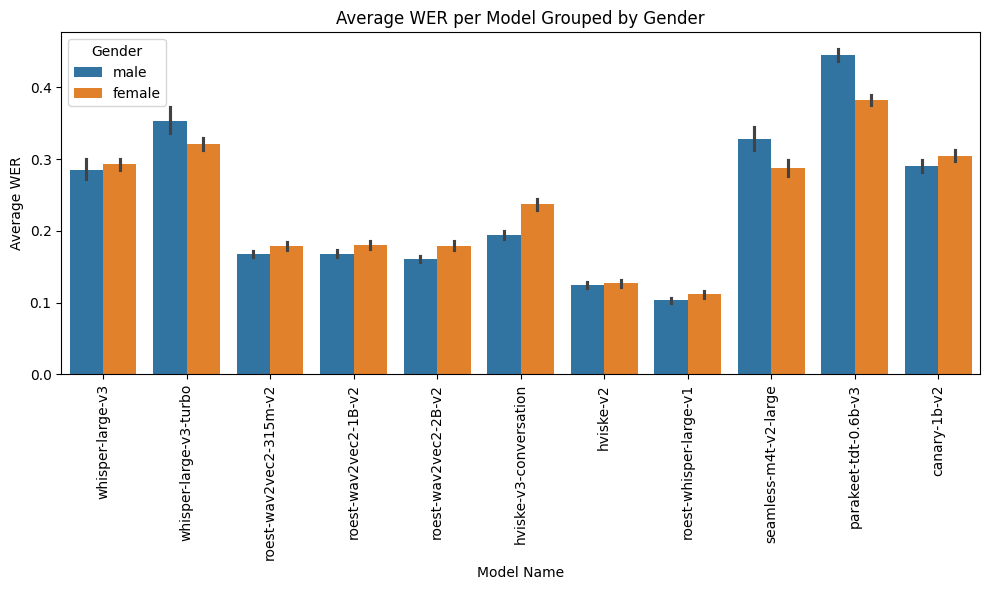

In [114]:
# plot avg wer barplot per model grouped by gender
plt.figure(figsize=(10, 6))
sns.barplot(
    data=df,
    x="model",
    y="WER",
    hue="gender",
    errorbar=('ci', 95)
)
plt.title("Average WER per Model Grouped by Gender")
plt.xlabel("Model Name")
plt.ylabel("Average WER")
plt.xticks(rotation=90)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

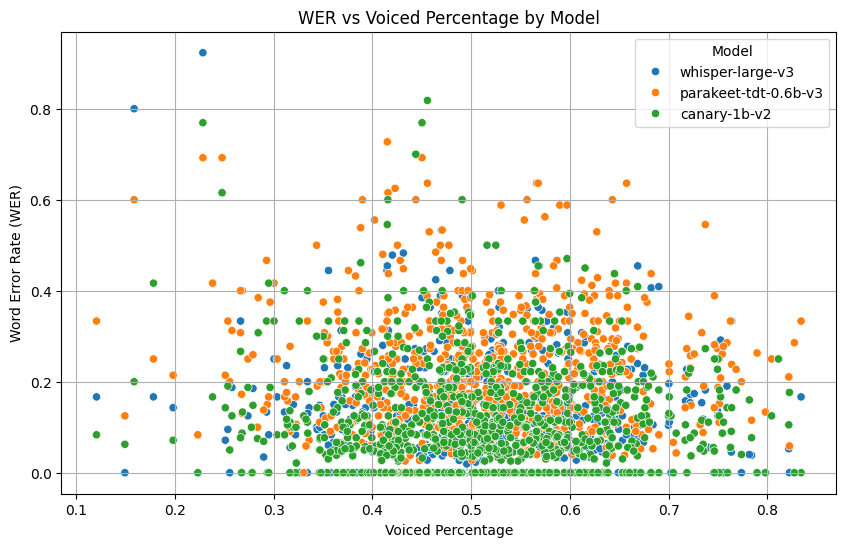

Model: whisper-large-v3, Pearson Correlation: -0.0362, P-value: 2.7006e-01
Model: parakeet-tdt-0.6b-v3, Pearson Correlation: 0.0105, P-value: 7.4866e-01
Model: canary-1b-v2, Pearson Correlation: -0.0436, P-value: 1.8420e-01


In [99]:
# 
models = ["whisper-large-v3", "parakeet-tdt-0.6b-v3", "canary-1b-v2"]
df_filtered = df[(df["model"].isin(models))]

# filter WER below 1.0
df_filtered = df_filtered[df_filtered["WER"] < 1.0]

# plot WER vs voiced percentage
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x="voiced_ratio", y="WER", hue="model")
plt.title("WER vs Voiced Percentage by Model")
plt.xlabel("Voiced Percentage")
plt.ylabel("Word Error Rate (WER)")
plt.legend(title="Model")
plt.grid(True)
plt.show()

# compute correlation coefficients
for model in models:
    subset = df_filtered[df_filtered["model"] == model]
    correlation, p_value = stats.pearsonr(subset["voiced_ratio"], subset["WER"])
    print(f"Model: {model}, Pearson Correlation: {correlation:.4f}, P-value: {p_value:.4e}")

ID: rec_d0c6e79cfae4b714c45ee78d5efcda29
Prediction: film er det primære på den otte og treds
Label: filmen havde premiere på den otteogtres
WER: 1.1666666666666667
Model: whisper-large-v3
-----
ID: rec_a7f1cbe76038fa0104854a792ffa0c15
Prediction: der er et skrivmål for skældet på talen
Label: bart skriver noget forskelligt på tavlen
WER: 1.1666666666666667
Model: whisper-large-v3
-----
ID: rec_36dda1d5c940a68da0f67579ce6e1923
Prediction: på den måde gik om så at han flere større anlægsarv og agvaduk
Label: således igangsatte han flere større anlægsarbejder af akvædukter
WER: 1.25
Model: whisper-large-v3
-----
ID: rec_d470c7d8c288fb3a1d9789b0a91fd648
Prediction: spænding dyrløg er pæs og den smag vi ikke som helst vil få til at sælge kan vi ikke slå en bil på sjældent
Label: spinning jewelry aps et en dansk smykkevirksomhed med hovedsæde i kongens lyngby på sjælland
WER: 1.6428571428571428
Model: whisper-large-v3
-----
ID: rec_66cf86d015dec83af560f8c1d98b5779
Prediction: sådan flere ti

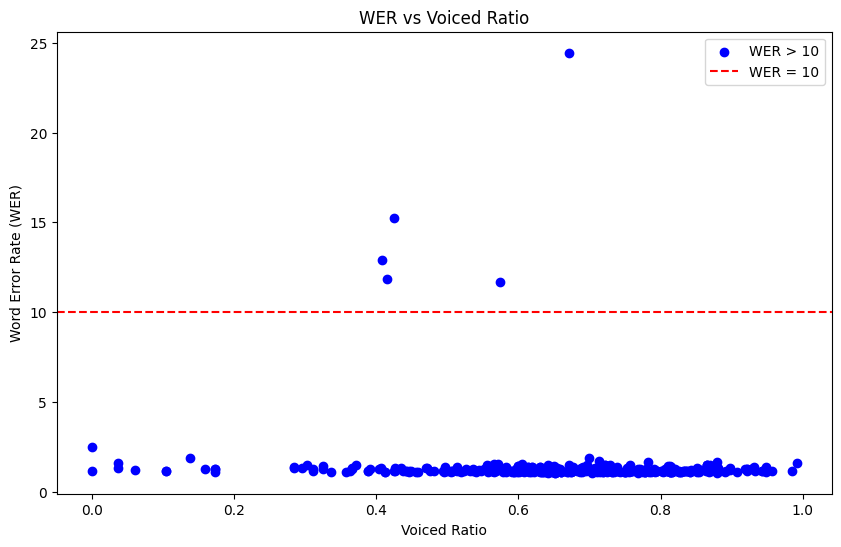

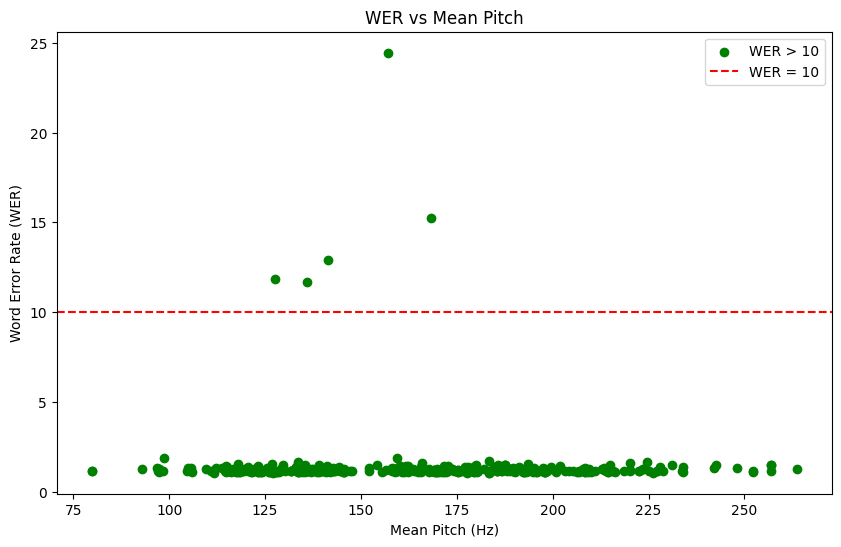

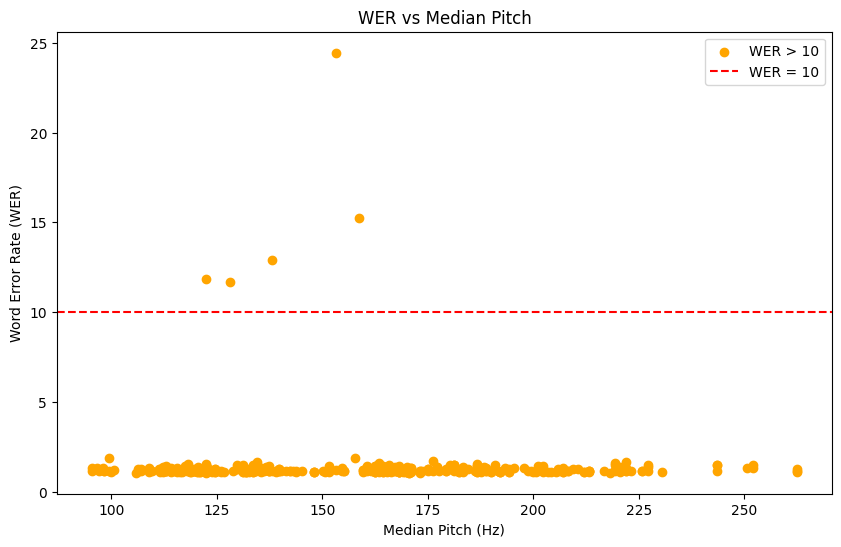

Number of samples with WER above 10: 354


In [48]:
# get all samples with WER above 10
# models
models = ["whisper-large-v3", "parakeet-tdt-0.6b-v3", "canary-1b-v2"]
df_high_wer = df[(df["WER"] > 1) & (df["model"].isin(models))]
# print all predictions and labels
for index, row in df_high_wer.iterrows():
    print(f"ID: {row['id']}")
    print(f"Prediction: {row['prediction']}")
    print(f"Label: {row['label']}")
    print(f"WER: {row['WER']}")
    # print model
    print(f"Model: {row['model']}")
    print("-----")

# make a plot of WER vs voiced_ratio
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df_high_wer["voiced_ratio"], df_high_wer["WER"], c='blue', label='WER > 10')
plt.xlabel("Voiced Ratio")
plt.ylabel("Word Error Rate (WER)")
plt.title("WER vs Voiced Ratio")
plt.axhline(y=10, color='r', linestyle='--', label='WER = 10')
plt.legend()
plt.show()

# also WER vs mean_pitch_hz
plt.figure(figsize=(10, 6))
plt.scatter(df_high_wer["mean_pitch_hz"], df_high_wer["WER"], c='green', label='WER > 10')
plt.xlabel("Mean Pitch (Hz)")
plt.ylabel("Word Error Rate (WER)")
plt.title("WER vs Mean Pitch")
plt.axhline(y=10, color='r', linestyle='--', label='WER = 10')
plt.legend()
plt.show()

# also WER vs median_pitch_hz
plt.figure(figsize=(10, 6))
plt.scatter(df_high_wer["median_pitch_hz"], df_high_wer["WER"], c='orange', label='WER > 10')
plt.xlabel("Median Pitch (Hz)")
plt.ylabel("Word Error Rate (WER)")
plt.title("WER vs Median Pitch")
plt.axhline(y=10, color='r', linestyle='--', label='WER = 10')
plt.legend()
plt.show()

# print the number of samples with WER above 10
print(f"Number of samples with WER above 10: {len(df_high_wer)}")

In [11]:
# setup function to play audio from samples
from IPython.display import Audio, display
def play_audio_from_sample(sample):
    audio_array = sample["audio"]["array"]
    sampling_rate = sample["audio"]["sampling_rate"]
    display(Audio(data=audio_array, rate=sampling_rate))

for sample in samples:
    if sample['id'] in [1825, 1889]:
        play_audio_from_sample(sample)

In [4]:
import librosa
import numpy as np

def extract_pitch_librosa(y, sr,
                          fmin=50,
                          fmax=350,
                          frame_length=2048,
                          hop_length=256):
    """
    Returns:
      f0_hz: numpy array of pitch values in Hz (NaN = unvoiced)
      voiced_ratio: fraction of voiced frames
      mean_pitch_hz: mean F0 over voiced frames
      median_pitch_hz: median F0 over voiced frames
    """
    # Ensure mono
    if y.ndim > 1:
        y = np.mean(y, axis=0)

    # Pitch tracking with pyin
    f0, voiced_flag, voiced_prob = librosa.pyin(
        y,
        fmin=fmin,
        fmax=fmax,
        sr=sr,
        frame_length=frame_length,
        hop_length=hop_length
    )

    # Remove unvoiced frames
    f0_voiced = f0[~np.isnan(f0)]

    if len(f0_voiced) == 0:
        return f0, 0.0, None, None

    return (
        f0,
        len(f0_voiced) / len(f0),
        float(np.mean(f0_voiced)),
        float(np.median(f0_voiced))
    )


In [6]:
# Cell 1: define the worker at top level
def process_sample(sample):
    audio = sample["audio"]["array"]
    sr = sample["audio"]["sampling_rate"]
    f0, voiced_ratio, mean_pitch_hz, median_pitch_hz = extract_pitch_librosa(audio, sr)
    return sample["id_recording"], {
        "voiced_ratio": voiced_ratio,
        "mean_pitch_hz": mean_pitch_hz,
        "median_pitch_hz": median_pitch_hz,
    }


In [7]:
# Cell 2: run multiprocessing
from multiprocessing import Pool
from tqdm import tqdm

if __name__ == "__main__":   # required in notebooks
    with Pool() as pool:
        results = pool.map(process_sample, evaluation_dataset, chunksize=16)

res = dict(results)


Process SpawnPoolWorker-5:
Traceback (most recent call last):
  File "/opt/miniconda3/envs/master/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/miniconda3/envs/master/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/miniconda3/envs/master/lib/python3.10/multiprocessing/pool.py", line 114, in worker
    task = get()
  File "/opt/miniconda3/envs/master/lib/python3.10/multiprocessing/queues.py", line 367, in get
    return _ForkingPickler.loads(res)
AttributeError: Can't get attribute 'process_sample' on <module '__main__' (built-in)>
Process SpawnPoolWorker-4:
Traceback (most recent call last):
  File "/opt/miniconda3/envs/master/lib/python3.10/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/opt/miniconda3/envs/master/lib/python3.10/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
  File "/opt/mini

KeyboardInterrupt: 

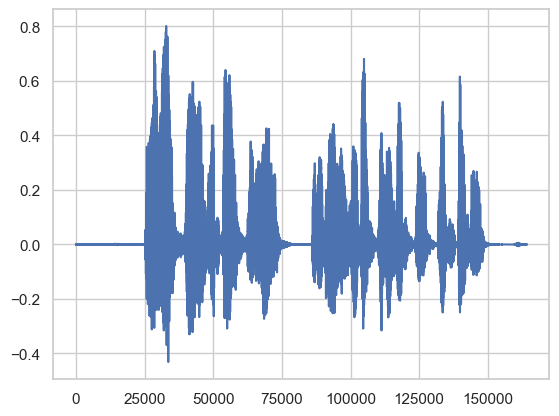

In [166]:
plt.plot(evaluation_dataset[0]['audio']['array'])

In [156]:
# compute number of words per second and add as a new column
df["num_words"] = df['label'].apply(lambda x: len(x.split()))
df['num_letters'] = df['label'].apply(lambda x: len(x.replace(" ", "")))
df["words_per_second"] = df["num_words"] / df['clip_length']
df['letters_per_second'] = df['num_letters'] / df['clip_length']

df.head()

,id,prediction,label,clip_length,CER,WER,model,dataset_name,dataset_subset,dataset_split,prediction_embedding,label_embedding,semantic_distance,num_words,num_letters,words_per_second,letters_per_second
0,rec_90dda503d68dc197f80219a7d3b129a9,derimod udøves retsplanen i det hele i det tid...,derimod udøvedes retsplejen i det hele i det t...,10.26,0.104167,0.266667,whisper-large-v3,coral-v2,read_aloud,test,"[-0.014361421, 0.05218921, -0.018706942, -0.09...","[-0.03685369, 0.03144104, -0.037021983, -0.117...",0.166795,15,82,1.461988,7.992203
1,rec_becc6eb53b441b31116584cd5c4e1c51,bauer klønge støtter kløngeorganisationer til ...,begge klynger støttes af klyngeorganisationer ...,7.32,0.234568,0.727273,whisper-large-v3,coral-v2,read_aloud,test,"[-0.07104228, -0.12548853, -0.06338177, -0.015...","[-0.0125311585, -0.060128797, -0.007917432, -0...",0.517030,11,71,1.502732,9.699454
2,rec_e59f62c2675fea5f9e7e726b51283250,i mildere tilfælde kan asmalt klare sig med pa...,i mildere tilfælde kan smerterne klares med pa...,8.10,0.147059,0.300000,whisper-large-v3,coral-v2,read_aloud,test,"[0.019092456, -0.023992827, -0.031023178, 0.02...","[0.03683996, -0.028660791, 0.04380101, 0.11237...",0.347441,10,59,1.234568,7.283951
3,rec_a47501841f128c1e6eb7fdd21647aa14,grønt er et ørelov liges her gennem og umanget...,grant at ødelægge lees hær gennem udmattelse v...,9.96,0.376344,0.857143,whisper-large-v3,coral-v2,read_aloud,test,"[0.028158227, -0.008324441, 0.06434102, -0.056...","[-0.04051919, 0.16661945, 0.01602321, -0.03350...",0.748699,14,80,1.405622,8.032129
4,rec_9a4da4e1a39901165014ad7354ac8e4f,der er lavet scenarier der forsøger at vise hv...,der er lavet scenarier der søger at vise hvord...,5.82,0.038462,0.071429,whisper-large-v3,coral-v2,read_aloud,test,"[-0.12290491, -0.02050186, 0.007368673, -0.010...","[-0.11009042, -0.02908404, 0.0042077433, -0.00...",0.019895,14,65,2.405498,11.168385


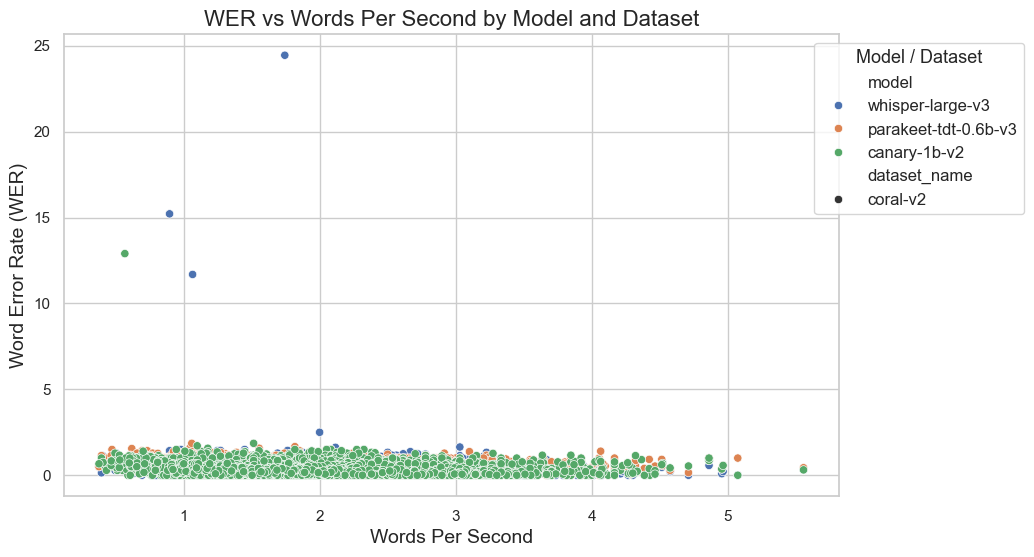

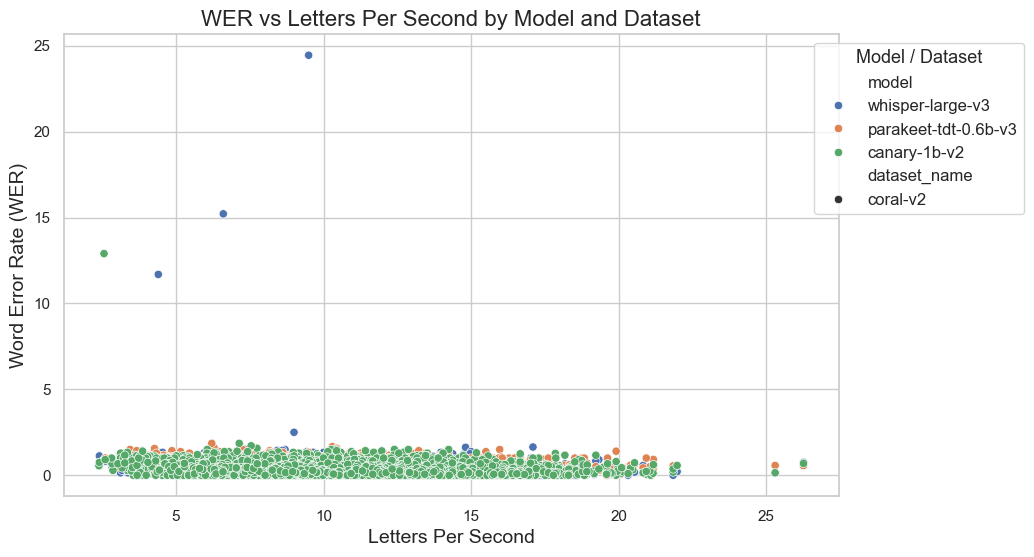

In [160]:
models = df['model'].unique().tolist()
datasets = df['dataset_name'].unique().tolist()

# only include parakeet-tdt-0.6b-v3, canary-1B-v2, and whisper-large-v3
models = [model for model in models if model in ['parakeet-tdt-0.6b-v3', 'canary-1b-v2', 'whisper-large-v3']]
datasets = [dataset for dataset in datasets if dataset in ['coral-v2']]

def plot_wer_vs_words_per_second(
        df: pd.DataFrame,
        models: Optional[List[str]] = None,
        datasets: Optional[List[str]] = None):
    
    """Plot WER vs words per second for different models and datasets.
    Args:
        models:
            List of model names to include in the plot. If None, include all models.
        datasets:
            List of dataset names to include in the plot. If None, include all datasets.
    """
    filtered_df = df.copy()
    if models is not None:
        filtered_df = filtered_df[filtered_df['model'].isin(models)]
    if datasets is not None:
        filtered_df = filtered_df[filtered_df['dataset_name'].isin(datasets)]
    # scatterplot of WER vs words per second
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=filtered_df, x='words_per_second', y='WER', hue='model', style='dataset_name')
    plt.title('WER vs Words Per Second by Model and Dataset', fontsize=16)
    plt.xlabel('Words Per Second', fontsize=14)
    plt.ylabel('Word Error Rate (WER)', fontsize=14)
    plt.legend(title='Model / Dataset', fontsize=12, title_fontsize=13, loc='upper right', bbox_to_anchor=(1.25, 1))
    plt.grid(True)
    plt.show()

# scatterplot of WER vs letters per second
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=filtered_df, x='letters_per_second', y='WER', hue='model', style='dataset_name')
    plt.title('WER vs Letters Per Second by Model and Dataset', fontsize=16)
    plt.xlabel('Letters Per Second', fontsize=14)
    plt.ylabel('Word Error Rate (WER)', fontsize=14)
    plt.legend(title='Model / Dataset', fontsize=12, title_fontsize=13, loc='upper right', bbox_to_anchor=(1.25, 1))
    plt.grid(True)
    plt.show()

plot_wer_vs_words_per_second(df, models=models, datasets=datasets)